In [ ]:
import os
import tifffile
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.utils import shuffle
import pandas as pd
import time
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

NUM_EPOCHS = 10
BATCH_SIZE = 1024
LEARNING_RATE = 0.0005
IS_GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if IS_GPU_AVAILABLE else "cpu")
print(f"Using device: {DEVICE}")
RANDOM_STATE = 42
TEST_SET_SIZE = 0.05
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

Using device: cuda


In [3]:
train_dir_path = "/kaggle/input/cloud-masking-dataset/content/train/data"
mask_dir_path = "/kaggle/input/cloud-masking-dataset/content/train/masks"
image_files = sorted([f for f in os.listdir(train_dir_path) if f.endswith((".tif", ".tiff"))])
mask_files = sorted([f for f in os.listdir(mask_dir_path) if f.endswith((".tif", ".tiff"))])

indices = np.arange(len(image_files))
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SET_SIZE,
    random_state=RANDOM_STATE,
    stratify=None
)
print(f"Total images: {len(indices)}")
print(f"Training + Validation indices: {len(train_val_idx)}")
print(f"Test indices: {len(test_idx)}")


Total images: 10573
Training + Validation indices: 10044
Test indices: 529


In [4]:
def preprocess_image_data(image, mask):
    image = image.astype(np.float32) / 65536.0 
    mask = (mask > 0).astype(np.uint8) 
    return image, mask


def extract_features_and_labels(image_indices, img_dir, msk_dir, image_filenames, mask_filenames, n_samples_per_image=1000, random_state=None):
    all_features = []
    all_labels = []

    if random_state is not None:
        np.random.seed(random_state)

    print(f"Extracting features from {len(image_indices)} images...")
    
    image_iterator = tqdm(image_indices, desc="Extracting Features", unit="image", leave=False)
    for idx in image_iterator:
        img_path = os.path.join(img_dir, image_filenames[idx])
        mask_path = os.path.join(msk_dir, mask_filenames[idx])

        if not Path(img_path).exists() or not Path(mask_path).exists():
            tqdm.write(f"Warning: Skipping index {idx}, file not found: {img_path} or {mask_path}")
            continue

        img = tifffile.imread(img_path)
        msk = tifffile.imread(mask_path)

        
        if img is None or msk is None or img.size == 0 or msk.size == 0:
             tqdm.write(f"Warning: Skipping index {idx} due to empty or invalid image/mask read.")
             continue
        if img.shape[:2] != msk.shape[:2]:
             tqdm.write(f"Warning: Skipping index {idx} due to shape mismatch between image {img.shape} and mask {msk.shape}.")
             continue

        img_prep, msk_prep = preprocess_image_data(img, msk)

        h, w, c = img_prep.shape
        img_reshaped = img_prep.reshape(-1, c)
        msk_reshaped = msk_prep.reshape(-1)

        num_pixels = h * w
        actual_samples = min(n_samples_per_image, num_pixels)
        if actual_samples == 0:
            tqdm.write(f"Warning: Image {idx} has 0 pixels after reshape, skipping.")
            continue

        sample_indices = np.random.choice(num_pixels, size=actual_samples, replace=False)

        sampled_features = img_reshaped[sample_indices]
        sampled_labels = msk_reshaped[sample_indices]

        all_features.append(sampled_features)
        all_labels.append(sampled_labels)

    if not all_features:
         
         c_fallback = tifffile.imread(os.path.join(img_dir, image_filenames[image_indices[0]])).shape[-1] if image_indices.size > 0 else 3
         return np.array([]).reshape(0,c_fallback), np.array([])

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)
    
    X = X.astype(np.float32)
    y = y.astype(np.float32) 

    print(f"Extracted features shape: {X.shape}, Labels shape: {y.shape}")
    return X, y

In [5]:
num_train_images_to_sample = min(len(train_val_idx), 7500)
print(f"Sampling features from {num_train_images_to_sample} training images...")
train_sample_indices = np.random.choice(train_val_idx, size=num_train_images_to_sample, replace=False)

X_train_sampled, y_train_sampled = extract_features_and_labels(
    train_sample_indices,
    train_dir_path,
    mask_dir_path,
    image_files,
    mask_files,
    n_samples_per_image=500,
    random_state=RANDOM_STATE
)


X_train_sampled, y_train_sampled = shuffle(X_train_sampled, y_train_sampled, random_state=RANDOM_STATE)


print("Scaling features...")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sampled)
joblib.dump(scaler, 'logreg_scaler.pkl') 


Sampling features from 7500 training images...
Extracting features from 7500 images...


Extracted features shape: (3750000, 4), Labels shape: (3750000,)
Scaling features...


['logreg_scaler.pkl']

In [6]:
class PixelDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features.astype(np.float32))
        self.labels = torch.from_numpy(labels.astype(np.float32)).unsqueeze(1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = PixelDataset(X_train_scaled, y_train_sampled)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

In [7]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        outputs = self.linear(x)
        return outputs

input_dim = X_train_scaled.shape[1]
pytorch_model = LogisticRegression(input_dim).to(DEVICE)

In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=LEARNING_RATE)

print("Training PyTorch Logistic Regression model...")
start_time = time.time()

pytorch_model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for inputs, labels in batch_iterator:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = pytorch_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_iterator.set_postfix(loss=f"{loss.item():.4f}")

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Average Loss: {avg_epoch_loss:.4f}")

end_time = time.time()
print(f"PyTorch training complete. Time taken: {end_time - start_time:.2f} seconds.")

torch.save(pytorch_model.state_dict(), 'pytorch_logreg_cloud_masker.pth')

scaler = joblib.load('logreg_scaler.pkl')
loaded_model = LogisticRegression(input_dim).to(DEVICE)
loaded_model.load_state_dict(torch.load('pytorch_logreg_cloud_masker.pth', map_location=DEVICE))
loaded_model.eval()


Training PyTorch Logistic Regression model...


Epoch [1/10], Average Loss: 0.5403


Epoch [2/10], Average Loss: 0.4891


Epoch [3/10], Average Loss: 0.4574


Epoch [4/10], Average Loss: 0.4381


...

Epoch [8/10], Average Loss: 0.4131


Epoch [9/10], Average Loss: 0.4112


Epoch [10/10], Average Loss: 0.4097
PyTorch training complete. Time taken: 239.86 seconds.


/tmp/ipykernel_31/2169233976.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('pytorch_logreg_cloud_masker.pth', map_location=DEV

LogisticRegression(
  (linear): Linear(in_features=4, out_features=1, bias=True)
)

In [10]:
def predict_pytorch_mask(image_path, model, scaler, device):
    if not Path(image_path).exists():
        print(f"Error: Image file not found for prediction: {image_path}")
        return None

    img = tifffile.imread(image_path)
    if img is None or img.size == 0:
        print(f"Warning: Image {os.path.basename(image_path)} is empty or invalid.")
        return None

    dummy_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    img_prep, _ = preprocess_image_data(img, dummy_mask)

    h, w, c = img_prep.shape
    if h * w == 0:
        print(f"Warning: Image {os.path.basename(image_path)} has zero size after processing.")
        return None
    img_reshaped = img_prep.reshape(-1, c)

    img_scaled_np = scaler.transform(img_reshaped.astype(np.float32))
    img_tensor = torch.from_numpy(img_scaled_np).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probabilities = torch.sigmoid(logits)
        pixel_predictions = (probabilities > 0.5).byte()

    predicted_mask_np = pixel_predictions.cpu().numpy()
    predicted_mask = predicted_mask_np.reshape(h, w).astype(np.uint8)

    return predicted_mask

In [11]:
from tqdm import tqdm 
def dice_coefficient_numpy(y_pred, y_true, epsilon=1e-6):
    y_pred = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_true).astype(bool)

    y_pred_f = y_pred.flatten()
    y_true_f = y_true.flatten()

    intersection = np.sum(y_true_f & y_pred_f)
    sum_A = np.sum(y_true_f)
    sum_B = np.sum(y_pred_f)

    dice = (2. * intersection + epsilon) / (sum_A + sum_B + epsilon)
    return dice

print("\nEvaluating PyTorch Logistic Regression on Test Set...")
test_dice_scores = []
test_times = []

max_eval_images = 500
num_eval_images = min(max_eval_images, len(test_idx))

if num_eval_images == 0:
    print("No images available in the test set to evaluate.")
else:
    print(f"Evaluating on the first {num_eval_images} images of the test set...")
    eval_indices = test_idx[:num_eval_images]
    test_iterator = tqdm(eval_indices, desc=f"Evaluating Subset ({num_eval_images} images)", unit="image", leave=True)

    for idx in test_iterator:
        img_path = os.path.join(train_dir_path, image_files[idx])
        true_mask_path = os.path.join(mask_dir_path, mask_files[idx])

        if not Path(img_path).exists() or not Path(true_mask_path).exists():
            tqdm.write(f"Warning: Skipping test index {idx}, file not found.")
            continue

        pred_start_time = time.time()
        predicted_mask_pytorch = predict_pytorch_mask(img_path, loaded_model, scaler, DEVICE)
        pred_end_time = time.time()
        test_times.append(pred_end_time - pred_start_time)

        if predicted_mask_pytorch is not None:
            true_mask = tifffile.imread(true_mask_path)
            if true_mask is None or true_mask.size == 0:
                 tqdm.write(f"Warning: Skipping test index {idx}, true mask is empty or invalid.")
                 continue
            dummy_img_for_mask_prep = np.zeros((*true_mask.shape[:2], 1), dtype=np.uint8)
            _, true_mask_prep = preprocess_image_data(dummy_img_for_mask_prep, true_mask)

            if predicted_mask_pytorch.shape != true_mask_prep.shape:
                tqdm.write(f"Warning: Shape mismatch for index {idx}. Predicted: {predicted_mask_pytorch.shape}, True: {true_mask_prep.shape}. Skipping.")
                continue

            dice = dice_coefficient_numpy(predicted_mask_pytorch, true_mask_prep)
            test_dice_scores.append(dice)

            if test_dice_scores:
                current_avg_dice = np.mean(test_dice_scores)
                current_avg_time = np.mean(test_times)
                test_iterator.set_postfix(avg_dice=f"{current_avg_dice:.4f}", avg_time=f"{current_avg_time:.4f}s", refresh=True)

        else:
            tqdm.write(f"Skipping evaluation for image index {idx} due to prediction error.")


    if test_dice_scores:
        avg_test_dice = np.mean(test_dice_scores)
        avg_test_time = np.mean(test_times) if test_times else 0
        print(f"\nFinal Average Dice Coefficient on {len(test_dice_scores)}/{num_eval_images} evaluated test images (PyTorch LogReg): {avg_test_dice:.4f}")
        print(f"Final Average Prediction Time per Image (PyTorch LogReg): {avg_test_time:.4f} seconds")
    elif num_eval_images > 0 :
        print(f"\nNo test scores calculated for the evaluated subset of {num_eval_images} images (all failed or were skipped).")



Evaluating PyTorch Logistic Regression on Test Set...
Evaluating on the first 500 images of the test set...


Evaluating Subset (500 images): 100%|██████████| 500/500 [00:28<00:00, 17.54image/s, avg_dice=0.7033, avg_time=0.0409s]


Final Average Dice Coefficient on 500/500 evaluated test images (PyTorch LogReg): 0.7033
Final Average Prediction Time per Image (PyTorch LogReg): 0.0409 seconds



Visualizing some PyTorch Logistic Regression predictions on test set...


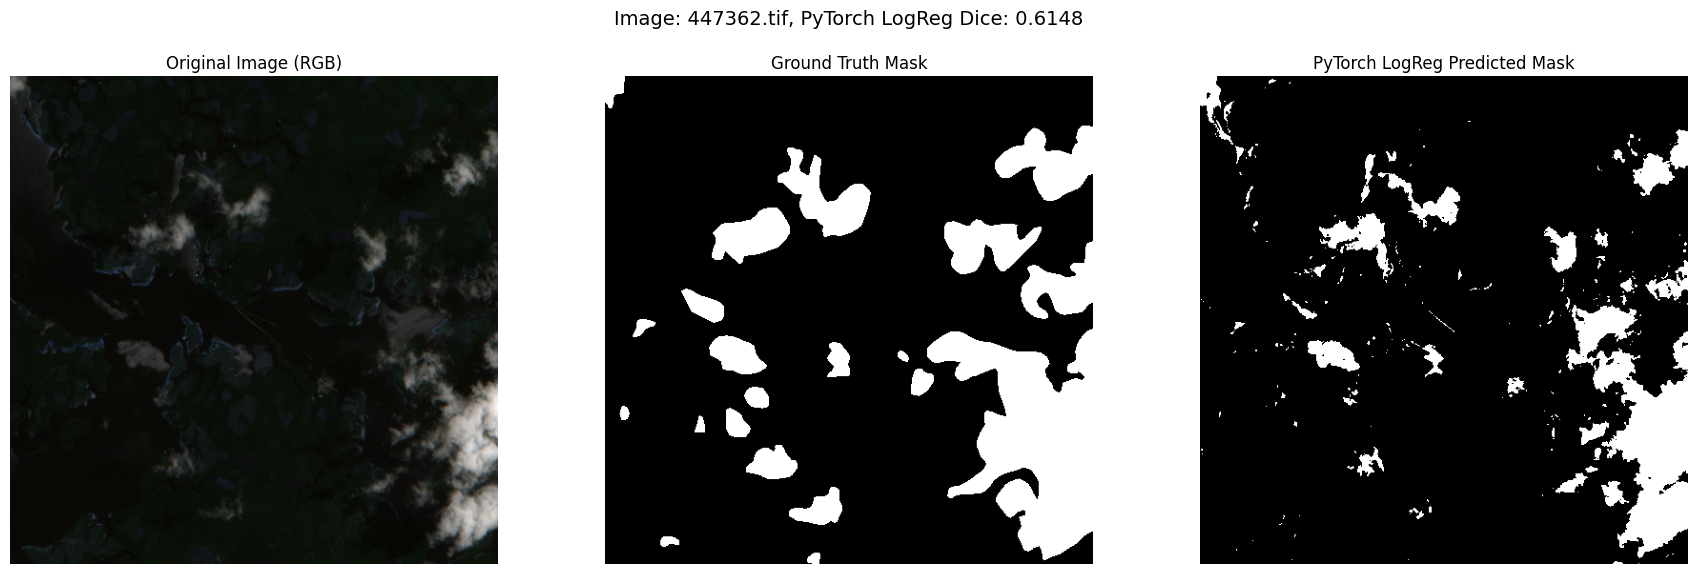

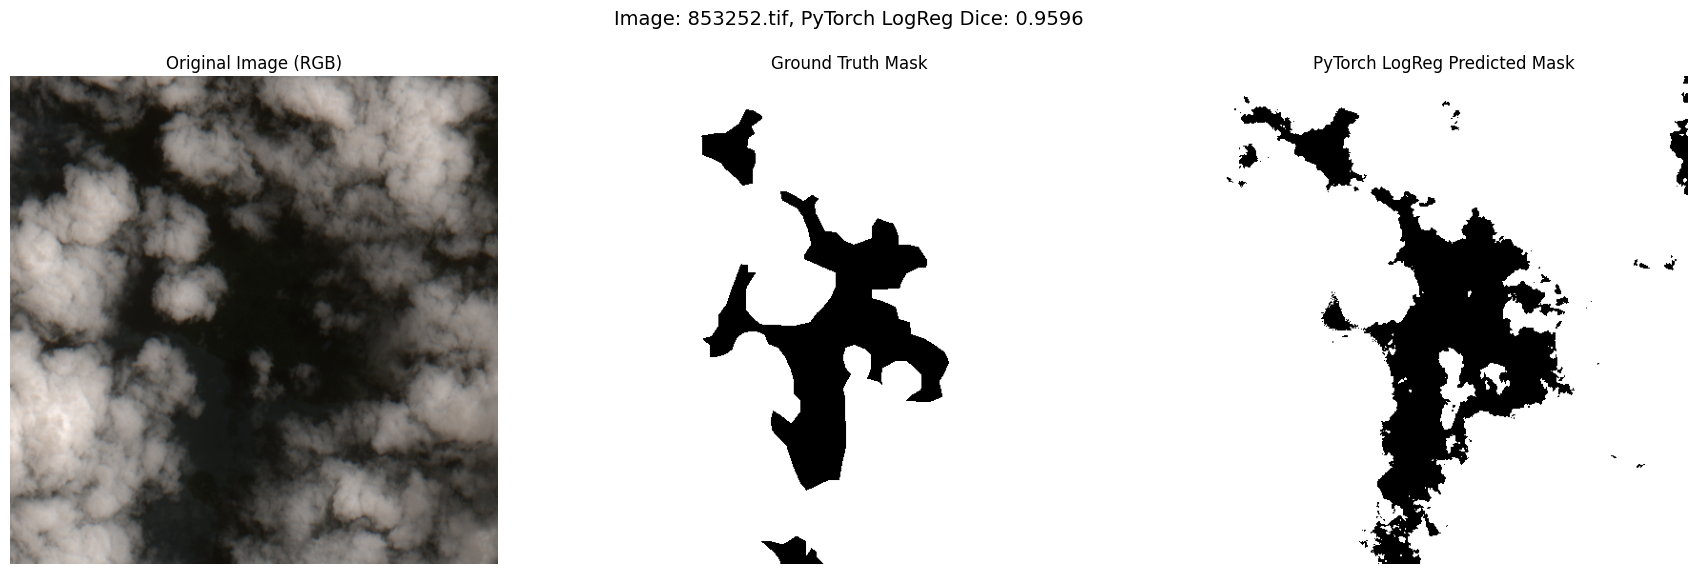

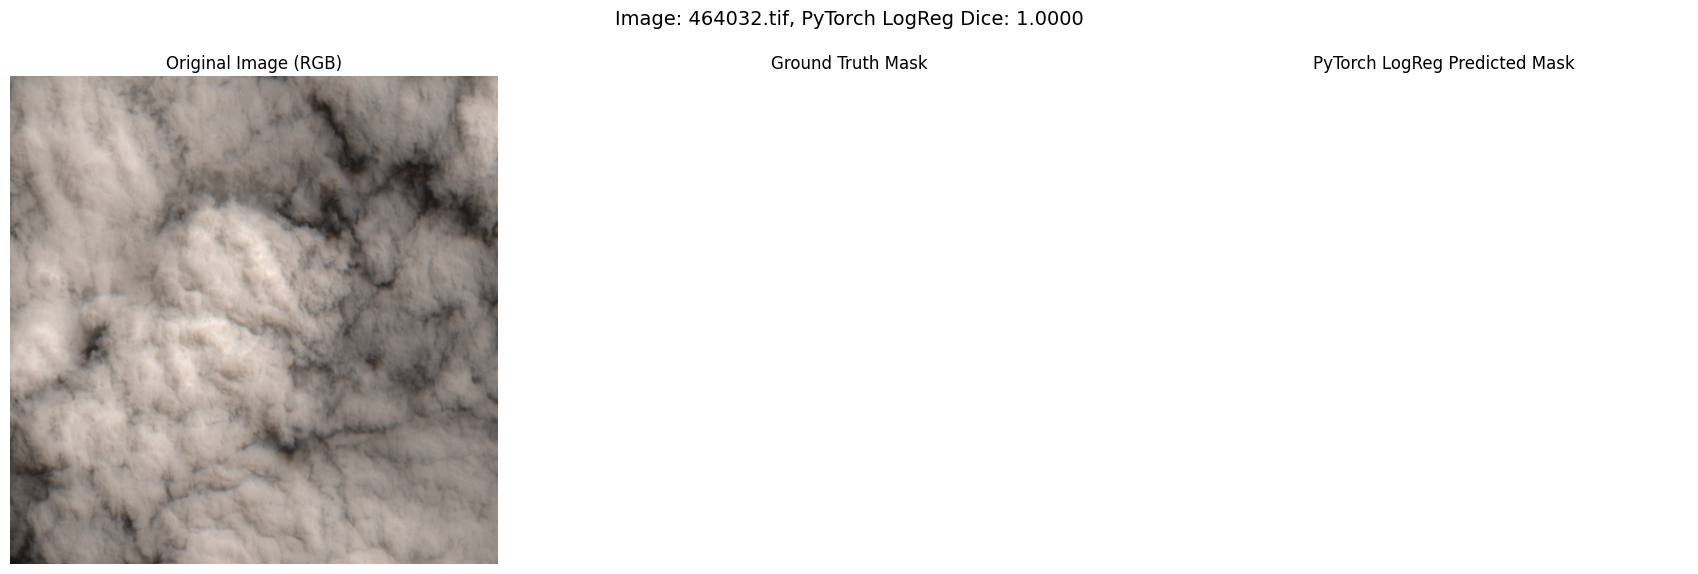

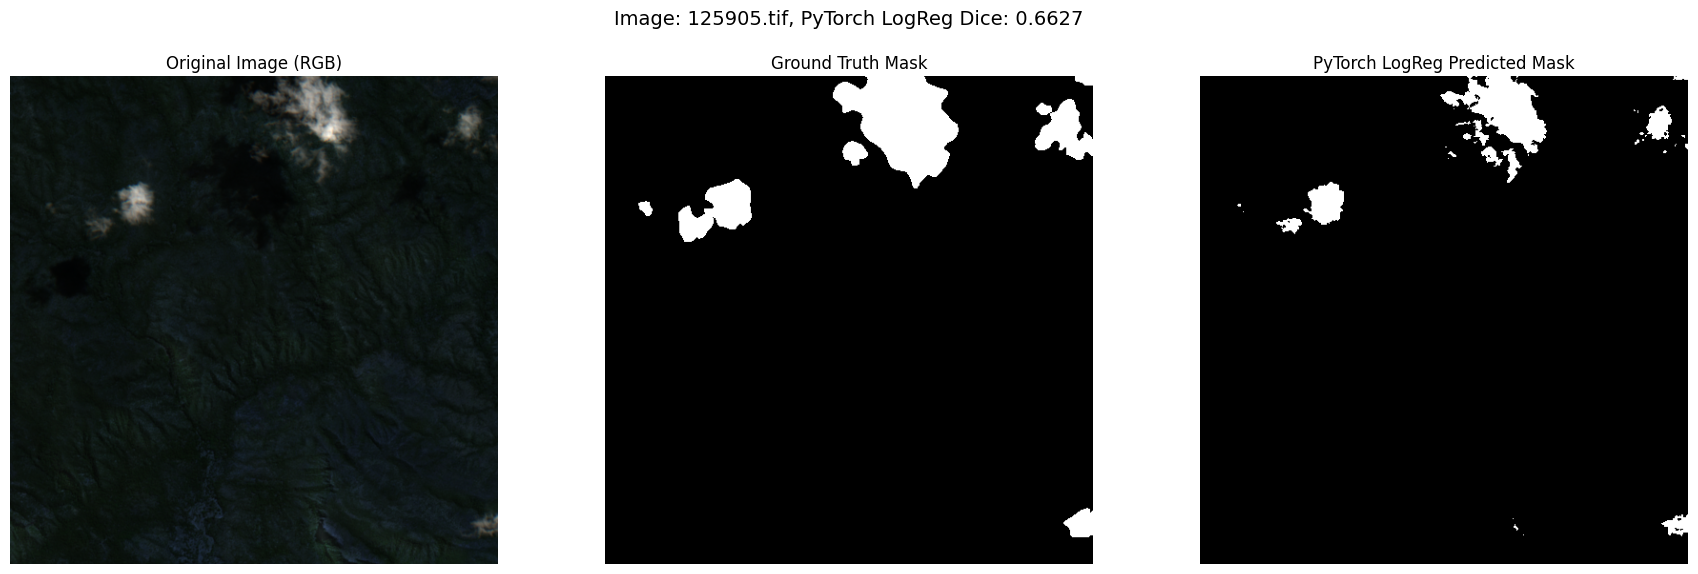

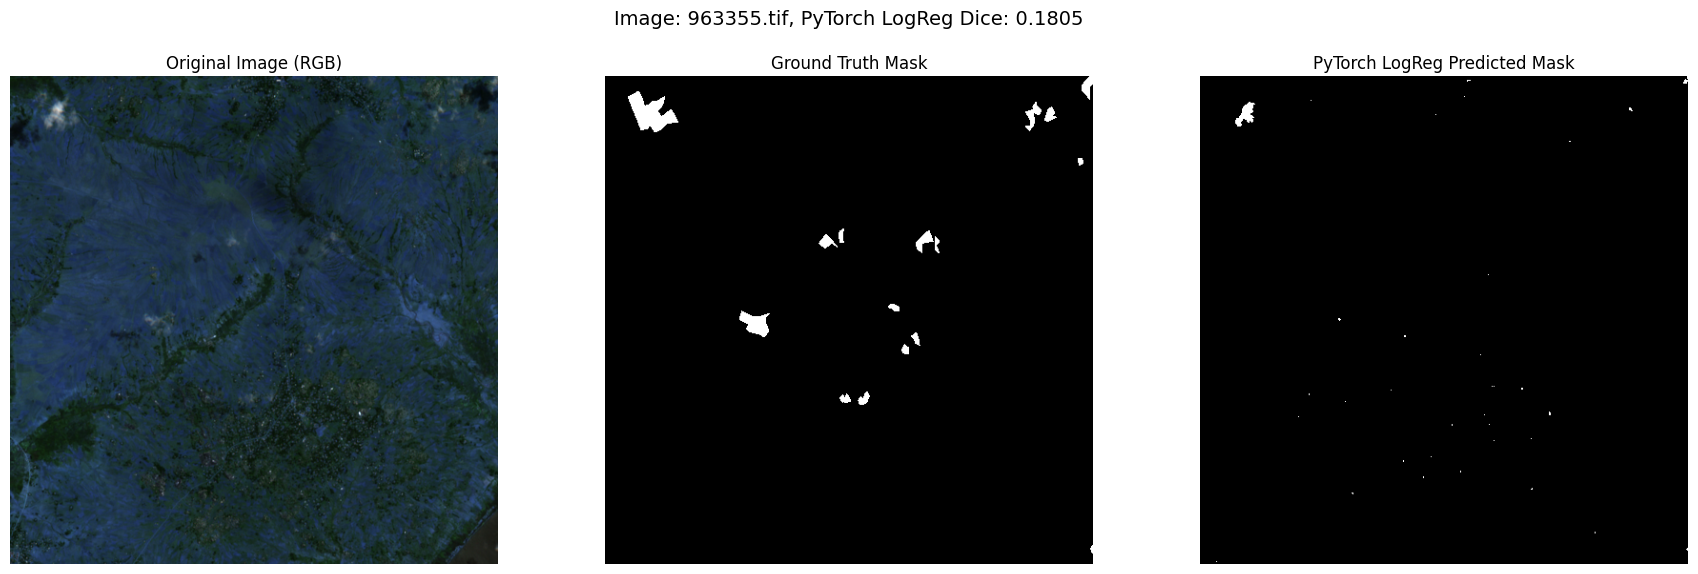

In [12]:
def visualize_pytorch_predictions(image_indices, model, scaler, img_dir, msk_dir, image_filenames, mask_filenames, device, num_to_show=20):
    count = 0
    valid_indices = [idx for idx in image_indices if idx < len(image_filenames) and idx < len(mask_filenames)]
    if not valid_indices:
        print("No valid image indices provided for visualization.")
        return

    indices_to_show = np.random.choice(valid_indices, min(num_to_show, len(valid_indices)), replace=False)

    for idx in indices_to_show:
        img_path = os.path.join(img_dir, image_filenames[idx])
        mask_path = os.path.join(msk_dir, mask_filenames[idx])

        if not Path(img_path).exists() or not Path(mask_path).exists():
            print(f"Warning: Skipping visualization for index {idx}, file not found.")
            continue

        img_orig = tifffile.imread(img_path)
        if img_orig is None or img_orig.size == 0:
            print(f"Warning: Skipping visualization for index {idx}, failed to read image.")
            continue

        if img_orig.ndim >= 3 and img_orig.shape[2] >= 3:
            rgb_image = img_orig[:, :, :3]
        elif img_orig.ndim == 2:
            rgb_image = np.stack([img_orig]*3, axis=-1)
        else:
            print(f"Warning: Cannot derive RGB from image shape {img_orig.shape} for index {idx}. Skipping visualization.")
            continue

        img_max = rgb_image.max()
        if img_max > 0:
             rgb_image = rgb_image.astype(np.float32) / float(img_max)
        rgb_image = np.clip(rgb_image, 0, 1)

        true_mask = tifffile.imread(mask_path)
        if true_mask is None or true_mask.size == 0:
            print(f"Warning: Skipping visualization for index {idx}, failed to read true mask.")
            continue
        dummy_img_for_mask_prep = np.zeros((*true_mask.shape[:2], 1), dtype=np.uint8)
        _, true_mask_prep = preprocess_image_data(dummy_img_for_mask_prep, true_mask)

        predicted_mask = predict_pytorch_mask(img_path, model, scaler, device)

        if predicted_mask is not None:
            dice = dice_coefficient_numpy(predicted_mask, true_mask_prep)

            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f"Image: {os.path.basename(img_path)}, PyTorch LogReg Dice: {dice:.4f}", fontsize=14)

            axes[0].imshow(rgb_image)
            axes[0].set_title("Original Image (RGB)")
            axes[0].axis('off')

            axes[1].imshow(true_mask_prep, cmap='gray', vmin=0, vmax=1)
            axes[1].set_title("Ground Truth Mask")
            axes[1].axis('off')

            axes[2].imshow(predicted_mask, cmap='gray', vmin=0, vmax=1)
            axes[2].set_title("PyTorch LogReg Predicted Mask")
            axes[2].axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            count += 1
        else:
            print(f"Skipping visualization for index {idx} due to prediction returning None.")


print("\nVisualizing some PyTorch Logistic Regression predictions on test set...")
visualize_pytorch_predictions(test_idx, loaded_model, scaler, train_dir_path, mask_dir_path, image_files, mask_files, DEVICE, num_to_show=5)